# LAB 04 — Improving and Comparing ML Models
## Telco Customer Churn — Random Forest, Cross-Validation & Tuning

## Student Information
**Name:**
**Student ID:**
**Section:**
**GitHub:**
**Kaggle:**
**Dataset:** Telco Customer Churn (Kaggle)

**Duration:** 3 Hours (independent, hands-on)

> This notebook is a **template**, not a tutorial. You already know Python, Pandas, EDA, and Decision Trees. Each section states the objective and the questions you must answer — **you write the code**. Every table, plot, and metric needs a short written observation.
>
> Submit **only this one notebook**. Keep every Markdown heading below — they are used for grading. Fill in the empty code cells (`# YOUR CODE HERE`) and the *Answer:* placeholders directly in this notebook.

---

## Setup

Import what you'll need. Add any other scikit-learn imports as you go.

In [1]:
# YOUR CODE HERE
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report


---

## 1. Decision Tree Baseline

Before improving anything, re-establish your Lab 3 Decision Tree result as the benchmark for this lab.

*Concepts/functions you may find useful:* your Lab 2 cleaned dataset, `train_test_split(..., stratify=y)`, `DecisionTreeClassifier(max_depth=...)`

**Tasks**
1. Re-load your cleaned Lab 2 dataset and recreate the same X/y and train/test split you used in Lab 3 (same `random_state`).
2. Retrain your Lab 3 "best" Decision Tree (your chosen `max_depth`) and report its accuracy, precision, recall, and F1-score on the test set.

In [2]:
# Task 1 — re-load cleaned dataset, recreate X/y and train/test split
df = pd.read_csv("clean_churn.csv")

y = df["Churn"].map({"No" : 0 , "Yes" : 1})
X = df.drop(columns = ["Churn"])

df.head()

X = pd.get_dummies(X,drop_first=True)

X_train , X_test , y_train , y_test = train_test_split(X,y, test_size = 0.2 , random_state=42 , stratify = y)


X_train.shape
X_test.shape
y_train.shape
y_test.shape


(1405,)

In [3]:
# Task 2 — retrain Lab 3 Decision Tree, report test-set metrics
model = DecisionTreeClassifier(max_depth = 5 , random_state = 42)

model.fit(X_train , y_train)

y_pred = model.predict(X_test)

acc = accuracy_score(y_test , y_pred)
precision = precision_score(y_test , y_pred)
recall = recall_score(y_test , y_pred)
f1 = f1_score(y_test , y_pred)


print("Accuracy :", acc)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)

Accuracy : 0.7871886120996441
Precision: 0.6514522821576764
Recall   : 0.4220430107526882
F1-score : 0.5122349102773246


**Task 2 — Decision Tree Baseline Metrics**

| Metric | Value |
|---|---|
| Accuracy |0.78 |
| Precision |0.65 |
| Recall |0.42 |
| F1-score |0.51 |


---

## 2. Random Forest

A Random Forest trains many Decision Trees on bootstrapped samples and averages their predictions.

*Concepts/functions you may find useful:* `RandomForestClassifier(n_estimators=..., random_state=...)`, `.fit()`, `.predict()`

**Tasks**
3. Train a `RandomForestClassifier` on the same training data (reasonable default `n_estimators`, e.g. 100–300; fix `random_state`). Generate predictions on the test set.
4. In 1–2 sentences, explain in your own words why a Random Forest might generalize better than a single unrestricted Decision Tree.

In [4]:
# Task 3 — train Random Forest, predict on test set
rf = RandomForestClassifier(n_estimators=100 , random_state=42)
rf.fit(X_train , y_train)
y_rf_pred = rf.predict(X_test)

acc = accuracy_score(y_test , y_rf_pred)
precision = precision_score(y_test , y_rf_pred)
recall = recall_score(y_test , y_rf_pred)
f1 = f1_score(y_test , y_rf_pred)


print("Accuracy :", acc)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)

Accuracy : 0.7822064056939502
Precision: 0.6231343283582089
Recall   : 0.4489247311827957
F1-score : 0.521875


**Answer 4:**

A Random Forest combines the predictions of many Decision Trees instead of relying on a single tree. This reduces overfitting and makes the model more stable, which can help it generalize better to unseen data.

---

## 3. Model Evaluation

Evaluate the Random Forest the same rigorous way you evaluated the Decision Tree in Lab 3.

*Concepts/functions you may find useful:* `confusion_matrix`, `ConfusionMatrixDisplay`, `classification_report`

**Task**
5. Compute accuracy, precision, recall, and F1-score for the Random Forest on the test set, and plot its confusion matrix.

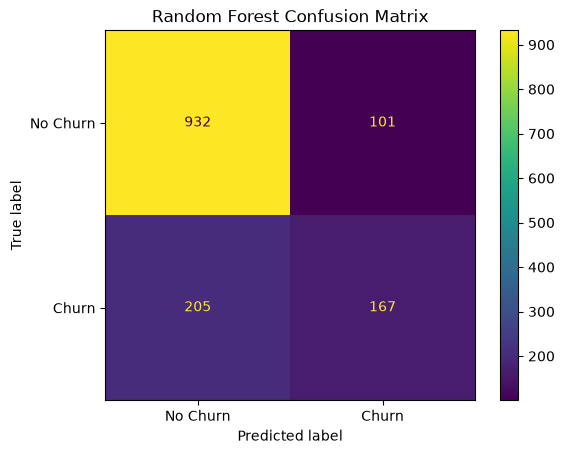

In [5]:
# Task 5 — Random Forest metrics + confusion matrix

# Confusion Matrix
cm = confusion_matrix(y_test, y_rf_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)

disp.plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

**Task 5 — Random Forest Metrics**


| Metric | Value |
|---|---|
| Accuracy |0.78 |
| Precision |0.62 |
| Recall |0.44 |
| F1-score |0.52 |

**Observation (confusion matrix):**

Correctly caught actual churners = 167

Missed actual churners = 205

---

## 4. Decision Tree vs Random Forest

Place both models side by side.

**Tasks**
6. Build a single comparison table: Decision Tree (Section 1) vs. Random Forest (Section 3), across all four metrics.
7. Which model performs better, and on which specific metric(s)? Is the difference large or marginal? Given Lab 2/3's finding about class imbalance, which metric matters most here?

**Task 6 — Comparison Table**


| Metric | Decision Tree | Random Forest |
|---|---|---|
| Accuracy |0.78 |0.78 |
| Precision |0.65 |0.62 |
| Recall |0.42 |0.44 |
| F1-score |0.51 |0.52 |

**Answer 7:**

The Random Forest performs slightly better overall than the Decision Tree. It has the same accuracy (0.78), slightly lower precision (0.62 vs. 0.65), but higher recall (0.44 vs. 0.42) and F1-score (0.52 vs. 0.51). Therefore, the improvement is marginal rather than large. Since the dataset has class imbalance, recall is particularly important because it measures how many actual churn customers are correctly identified. In this case, Random Forest has a slightly better recall, so it is preferable for identifying churners.

---

## 5. Cross-Validation

A single train/test split gives one noisy estimate of performance. k-fold cross-validation trains and tests the model k times on different splits.

*Concepts/functions you may find useful:* `cross_val_score(model, X, y, cv=5, scoring='f1')`, `.mean()`, `.std()`

**Tasks**
8. Run 5-fold cross-validation for both the Decision Tree and the Random Forest, using a metric other than plain accuracy (e.g. F1-score). Report the mean and standard deviation of each model's fold scores.
9. How do the cross-validated results compare to your single train/test split results from Section 4? Do they change your view of which model is better, or how confident you are in that conclusion?

In [6]:
# Task 8 — 5-fold cross-validation for both models

# Decision Tree
dt_scores = cross_val_score(model, X, y, cv=5, scoring='f1')

# Random Forest
rf_scores = cross_val_score(rf, X, y, cv=5, scoring='f1')

print("Decision Tree")
print("Fold scores:", dt_scores)
print("Mean:", dt_scores.mean())
print("Std:", dt_scores.std())

print("\nRandom Forest")
print("Fold scores:", rf_scores)
print("Mean:", rf_scores.mean())
print("Std:", rf_scores.std())


Decision Tree
Fold scores: [0.57013575 0.46998285 0.48184818 0.51752922 0.53375196]
Mean: 0.5146495912896955
Std: 0.036119126587306156

Random Forest
Fold scores: [0.54237288 0.54773083 0.51940299 0.55086072 0.56615385]
Mean: 0.545304252376036
Std: 0.015171926389197371


**Task 8 — Cross-Validation Results**

| Model | Mean F1 | Std F1 |
|---|---|---|
| Decision Tree |0.514 |0.036 |
| Random Forest |0.545 |0.015 |

**Answer 9:**

The cross-validated results are consistent with the single train/test split results. Random Forest still performs better than the Decision Tree, with a higher mean F1-score of 0.5453 compared to 0.5146 for the Decision Tree. Its lower standard deviation (0.0152 vs. 0.0361) also shows that Random Forest is more consistent across different folds. Therefore, the cross-validation results do not change my view that Random Forest is the better model; instead, they increase my confidence in this conclusion.

---

## 6. Hyperparameter Tuning

Search over a small grid of hyperparameters to see whether a tuned model meaningfully beats your default-settings baseline. Keep the search small — this is about the workflow, not an exhaustive search.

*Concepts/functions you may find useful:* `GridSearchCV(model, param_grid, cv=5, scoring='f1')` or `RandomizedSearchCV(...)`, `.best_params_`, `.best_score_`, `.best_estimator_`

**Tasks**
10. Choose 2–3 Random Forest hyperparameters to tune (e.g. `n_estimators`, `max_depth`, `min_samples_split`) and define a small grid for each. Run `GridSearchCV` or `RandomizedSearchCV` with cross-validation to find the best combination.
11. Report the best hyperparameters found and the corresponding cross-validated score.
12. Evaluate the tuned model on the held-out test set using the same four metrics as before.

In [7]:
# Task 10 — define a small param grid and run GridSearchCV / RandomizedSearchCV
# Random Forest model
rf_model = RandomForestClassifier(random_state=42)

param_grid = {
    "n_estimators": [100 ,200, 300],
    "max_depth": [8, 10, 12],
    "min_samples_split": [5, 10]
}

# Grid Search with 5-fold cross-validation
grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

# Train and search
grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validated F1-Score:")
print(grid_search.best_score_)


Best Parameters:
{'max_depth': 12, 'min_samples_split': 10, 'n_estimators': 300}

Best Cross-Validated F1-Score:
0.5810988515068897


**Answer 11 (best hyperparameters & CV score):**

The best hyperparameters found by GridSearchCV are:

max_depth: 12

min_samples_split: 10

n_estimators: 300

The corresponding best cross-validated F1-score is 0.5811.

This means that this combination of hyperparameters gave the best average F1-score across the 5 cross-validation folds.


In [8]:
# Task 12 — evaluate the tuned model on the test set
best_rf = grid_search.best_estimator_

y_pred_tuned = best_rf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred_tuned)
precision = precision_score(y_test, y_pred_tuned)
recall = recall_score(y_test, y_pred_tuned)
f1 = f1_score(y_test, y_pred_tuned)

print("Tuned Random Forest Results")
print("----------------------------")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-Score :", f1)


Tuned Random Forest Results
----------------------------
Accuracy : 0.79644128113879
Precision: 0.6546762589928058
Recall   : 0.489247311827957
F1-Score : 0.56


**Task 12 — Tuned Random Forest Metrics**

| Metric | Value |
|---|---|
| Accuracy |0.79 |
| Precision |0.65 |
| Recall |0.48 |
| F1-score |0.56 |

---

## 7. Final Model Comparison

Bring every model you've built into one table.

**Task**
13. Build one final comparison table across all models you trained: Decision Tree, default Random Forest, and tuned Random Forest — accuracy, precision, recall, F1-score for each.

**Task 13 — Final Comparison Table**

| Metric | Decision Tree | Random Forest (default) | Random Forest (tuned) |
|---|---|---|---|
| Accuracy | | | |
| Precision | | | |
| Recall | | | |
| F1-score | | | |

---

## 8. Feature Importance

Look inside your best-performing model to see what it actually learned.

*Concepts/functions you may find useful:* `model.feature_importances_`, `pd.Series(importances, index=X.columns).sort_values()`, `plt.barh(...)`

**Task**
14. Extract and visualize `feature_importances_` for your best model. Which 3–5 features matter most, and do they agree with what Lab 2's EDA and Lab 3's Decision Tree suggested?

In [ ]:
# Task 14 — extract and visualize feature importances


**Answer 14:**
_(your answer here)_

---

## 9. Final Model Selection

Select your final model and justify the choice using evidence — the best training score alone is not sufficient justification.

**Task**
15. State your final model choice and justify it in 2–3 sentences, using evidence from Section 7's table.

**Answer 15:**
_(your answer here)_

---

## 10. Kaggle Prediction/Submission

Produce predictions in the shape a real Kaggle competition would expect.

**Task**
16. Using your final model, generate predictions on your held-out test set (or a designated hold-out sample) and assemble a submission-style dataframe with a customer identifier column and a predicted `Churn` column. Save it as `submission.csv`.

In [ ]:
# Task 16 — build and save the submission file
# submission = pd.DataFrame({'customerID': ..., 'Churn': ...})
# submission.to_csv('submission.csv', index=False)


---

## 11. Conclusion

Step back from the code and summarize what you built and learned.

**Tasks**
17. Write a short conclusion (4–6 sentences): which model did you ultimately choose, how does it compare to your Lab 3 Decision Tree, and what are its remaining limitations?
18. What would you try next if you had more time (e.g. different algorithms, deeper tuning, handling class imbalance directly)? Describe it — do not implement it here.

**Answer 17 — Conclusion:**
_(your answer here)_

**Answer 18 — Next steps:**
_(your answer here)_

---

## Submission Checklist

Before submitting, confirm you have:

- [ ] Filled in the student-info block at the top (Name, Student ID, Section, GitHub, Kaggle, Dataset)
- [ ] Section 1 — Decision Tree Baseline
- [ ] Section 2 — Random Forest
- [ ] Section 3 — Model Evaluation
- [ ] Section 4 — Decision Tree vs Random Forest
- [ ] Section 5 — Cross-Validation
- [ ] Section 6 — Hyperparameter Tuning
- [ ] Section 7 — Final Model Comparison
- [ ] Section 8 — Feature Importance
- [ ] Section 9 — Final Model Selection (justified)
- [ ] Section 10 — Kaggle Prediction/Submission (submission.csv produced)
- [ ] Section 11 — Conclusion (limitations + next steps)
- [ ] Notebook exported/shared as a single Colab (.ipynb) file — no other files submitted